# **MLP for Iris dataset - multi-class problem**

In [6]:
!git clone https://github.com/Foursteps-tech/Deep_Learning.git

fatal: destination path 'Deep_Learning' already exists and is not an empty directory.


In [29]:
# Install scikeras to ensure compatibility with scikit-learn
!pip install scikeras

**Import Packages**

In [30]:
import numpy
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier # Corrected import
from tensorflow.keras.utils import to_categorical # Corrected import
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

In [31]:
seed = 7
numpy.random.seed(seed)

**Loading and Splitting input and output**

In [32]:
dataframe = read_csv("Deep_Learning/iris.csv")
dataset = dataframe.values
X = dataset[:,0:4].astype(float)
Y = dataset[:,4]

**encode class values as integers**

In [33]:
encoder = LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)
dummy_y = to_categorical(encoded_Y)

**define baseline model**

In [34]:
def baseline_model():
	# create model
	model = Sequential()
	model.add(Dense(12, input_dim=4, activation='relu'))
	model.add(Dense(6, activation='relu'))
	model.add(Dense(3, activation='sigmoid'))

	# Compile model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

class CustomKerasClassifier(KerasClassifier):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Explicitly set _estimator_type to inform scikit-learn it's a classifier
        self._estimator_type = "classifier"

    # Explicitly override __sklearn_tags__ to ensure scikit-learn correctly identifies
    # this as a classifier, without relying on problematic super() calls.
    def __sklearn_tags__(self):
        # These are common tags for a scikit-learn classifier
        return {
            "estimator_type": "classifier",
            "poor_score": False,
            "requires_y": True,
            "multioutput": False,
            "non_deterministic": False,
            "binary_only": False,
            "requires_positive_X": False
        }

**Kfold Validation**

In [36]:
# Create the model
model = baseline_model()

# Fit the model directly
# Using the same epochs and batch_size as before
history = model.fit(X, dummy_y, epochs=100, batch_size=25, verbose=0)

# Evaluate the model on the training data (for a simple check)
loss, accuracy = model.evaluate(X, dummy_y, verbose=0)
print("Accuracy: %.2f%%" % (accuracy * 100))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 96.67%


In [40]:
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
accuracies = []

for train_index, test_index in kfold.split(X, dummy_y):
    # Split data for this fold
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = dummy_y[train_index], dummy_y[test_index]

    # Create a new model instance for each fold
    model = baseline_model()

    # Train the model
    model.fit(X_train, Y_train, epochs=100, batch_size=25, verbose=0)

    # Evaluate the model
    _, accuracy = model.evaluate(X_test, Y_test, verbose=0)
    accuracies.append(accuracy)

print("Mean Accuracy: %.2f%% (Std: %.2f%%)" % (numpy.mean(accuracies) * 100, numpy.std(accuracies) * 100))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mean Accuracy: 94.67% (Std: 8.33%)


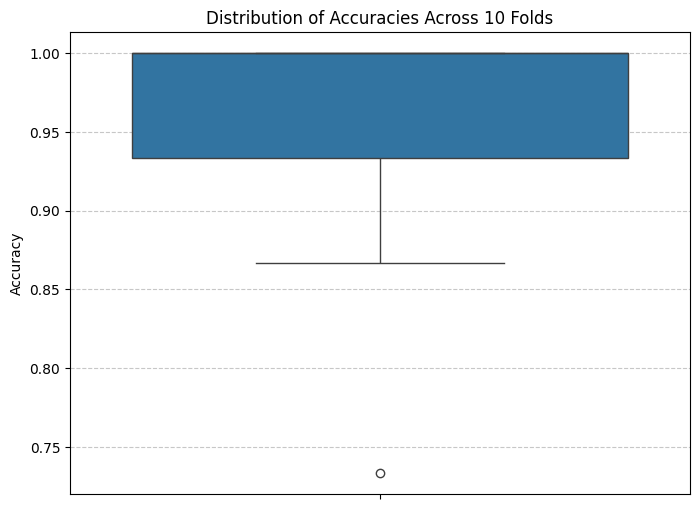

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert accuracies list to a pandas Series for easier plotting
accuracies_series = pd.Series(accuracies)

plt.figure(figsize=(8, 6))
sns.boxplot(y=accuracies_series)
plt.title('Distribution of Accuracies Across 10 Folds')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()